In [1]:
import random
import time
import collections
import matplotlib.pyplot as plt
import networkx as nx

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# definiton of input test cases spanning 2 orders of magnitude (100 -> 10,000)
TEST_CASES = [
    {"nodes": 100,   "edges": 300},
    {"nodes": 500,   "edges": 1500},
    {"nodes": 1000,  "edges": 3000},
    {"nodes": 5000,  "edges": 15000},
    {"nodes": 10000, "edges": 30000}
]

In [4]:
# Algorithm 1: Brute Force

def brute_force_betweenness(num_nodes, adj_list):
    """
    Computes exact betweenness centrality using a naive approach.
    Forces an explicit lookup via an Adjacency Matrix structure to model
    O(V^3) real-world worst-case performance limits.
    """

    adj_matrix = [[0] * num_nodes for _ in range(num_nodes)]
    for u in adj_list:
        for v in adj_list[u]:
            adj_matrix[u][v] = 1

    cb = [0.0] * num_nodes

    # iterate through all pairs (s, t) independently
    for s in range(num_nodes):
        for t in range(num_nodes):
            if s == t:
                continue

            # find all shortest paths from s,t via BFS
            queue = collections.deque([[s]])
            shortest_paths = []
            min_len = float('inf')

            while queue:
                path = queue.popleft()
                curr = path[-1]

                if len(path) > min_len:
                    continue

                if curr == t:
                    if len(path) < min_len:
                        min_len = len(path)
                        shortest_paths = [path]
                    elif len(path) == min_len:
                        shortest_paths.append(path)
                    continue

                # scan the raw matrix row
                for neighbor in range(num_nodes):
                    if adj_matrix[curr][neighbor] == 1 and neighbor not in path:
                        queue.append(path + [neighbor])

            # calculate fractional tracking contribution for intermediate nodes
            sigma_st = len(shortest_paths)
            if sigma_st == 0:
                continue

            for path in shortest_paths:
                # exclude target and source endpoints from calculation
                for node in path[1:-1]:
                    cb[node] += 1.0 / sigma_st

    # normalize score due to undirected pair counting: divide by 2
    for i in range(num_nodes):
        cb[i] /= 2.0
    return cb

In [5]:
# Algorithm 2: Brande's Algorithm

def brandes_betweenness(num_nodes, adj_list):
    """
    Computes exact betweenness centrality using Brandes' Algorithm.
    Uses an Adjacency List layout with a LIFO Stack backward traversal pass.
    Complexity: O(V * E)
    """
    cb = [0.0] * num_nodes

    for s in range(num_nodes):
        # initialization structures for single-source pass
        S = [] # unwind Stack
        P = [[] for _ in range(num_nodes)] # shortest path predecessors
        sigma = [0] * num_nodes # shortest path counters
        sigma[s] = 1
        dist = [-1] * num_nodes
        dist[s] = 0

        queue = collections.deque([s])

        # Forward Phase (Outward BFS)
        while queue:
            v = queue.popleft()
            S.append(v)
            for w in adj_list[v]:
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                # alternative shortest path connection found
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    P[w].append(v)

        # Backward Phase (Retrospective Dependency Accumulation)
        delta = [0.0] * num_nodes
        while S:
            w = S.pop()
            for v in P[w]:
                delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
            if w != s:
                cb[w] += delta[w]

    # normalize due to undirected duplicate edge paths
    for i in range(num_nodes):
        cb[i] /= 2.0
    return cb

In [7]:
# SYNTHETIC RECONNAISSANCE NETWORK GENERATOR

def generate_sparse_network(num_nodes, num_edges):
    """
    Generates a connected random graph represented as an adjacency list.
    Ensures connectivity so paths exist across the cell matrix.
    """
    adj_list = {i: [] for i in range(num_nodes)}
    edges_added = 0

    # ensure a baseline spanning tree structure to avoid isolated components
    for i in range(1, num_nodes):
        parent = random.randint(0, i - 1)
        adj_list[parent].append(i)
        adj_list[i].append(parent)
        edges_added += 1

    # fill remaining edges up to target constraints
    while edges_added < num_edges:
        u = random.randint(0, num_nodes - 1)
        v = random.randint(0, num_nodes - 1)
        if u != v and v not in adj_list[u]:
            adj_list[u].append(v)
            adj_list[v].append(u)
            edges_added += 1

    return adj_list

In [17]:
# BENCHMARK EXECUTION PIPELINE (THE SWEEP)
import signal

class TimeoutException(Exception):
    """Custom exception to catch algorithmic timeouts."""
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

brute_force_times = []
brandes_times = []
sizes_tested = []

# set the maximum allowed time per algorithm run in seconds
TIMEOUT_LIMIT = 300

print("=" * 65)
print(f"STARTING CORE BENCHMARK SWEEP (SEED: {RANDOM_SEED} | TIMEOUT: {TIMEOUT_LIMIT}s)")
print("=" * 65)

for tc in TEST_CASES:
    n = tc["nodes"]
    m = tc["edges"]
    sizes_tested.append(n)

    # generate the network model instance
    network = generate_sparse_network(n, m)
    print(f"Configuring Graph: V={n}, E={m}...")

    # 1. Execute Brandes implementation across all sizes
    start_time = time.time()
    brandes_scores = brandes_betweenness(n, network)
    brandes_duration = time.time() - start_time
    brandes_times.append(brandes_duration)
    print(f" -> Brandes Completed: {brandes_duration:.4f} seconds")

    # 2. Execute Brute Force protected by an interrupt alarm
    # Assign the handler to the SIGALRM signal

    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(TIMEOUT_LIMIT)

    try:
        start_time = time.time()
        brute_scores = brute_force_betweenness(n, network)
        brute_duration = time.time() - start_time
        brute_force_times.append(brute_duration)
        print(f" -> Brute Force Completed: {brute_duration:.4f} seconds")
        signal.alarm(0)  # cancel the alarm if it finished under the limit

    except TimeoutException:
        print(f" -> Brute Force Skipped for V={n}: Runtime too long (Exceeded {TIMEOUT_LIMIT}s limit)")
        brute_force_times.append(None)

    finally:
        signal.alarm(0)

STARTING CORE BENCHMARK SWEEP (SEED: 42 | TIMEOUT: 300s)
Configuring Graph: V=100, E=300...
 -> Brandes Completed: 0.0127 seconds
 -> Brute Force Completed: 23.2873 seconds
Configuring Graph: V=500, E=1500...
 -> Brandes Completed: 0.5642 seconds
 -> Brute Force Skipped for V=500: Runtime too long (Exceeded 300s limit)
Configuring Graph: V=1000, E=3000...
 -> Brandes Completed: 1.5750 seconds
 -> Brute Force Skipped for V=1000: Runtime too long (Exceeded 300s limit)
Configuring Graph: V=5000, E=15000...
 -> Brandes Completed: 62.3722 seconds
 -> Brute Force Skipped for V=5000: Runtime too long (Exceeded 300s limit)
Configuring Graph: V=10000, E=30000...
 -> Brandes Completed: 301.6767 seconds
 -> Brute Force Skipped for V=10000: Runtime too long (Exceeded 300s limit)


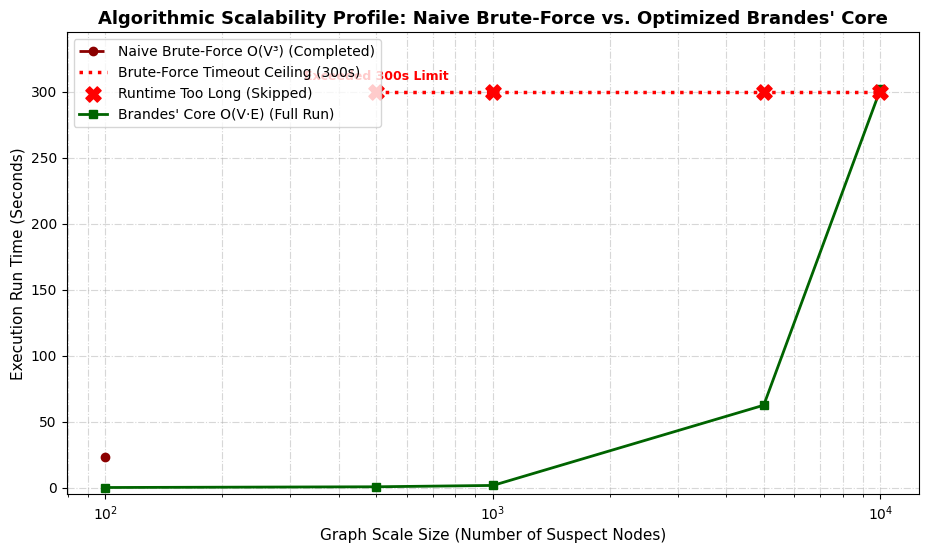

In [19]:
# PLOTTING PERFORMANCE CURVES (WITH EXPLICIT TIMEOUT CEILING VISUALIZATION)

plt.figure(figsize=(11, 6))

# 1. Separate valid completions vs. timeout skips for Brute Force
valid_brute_x = [sizes_tested[i] for i in range(len(brute_force_times)) if brute_force_times[i] is not None]
valid_brute_y = [t for t in brute_force_times if t is not None]

timeout_x = [sizes_tested[i] for i in range(len(brute_force_times)) if brute_force_times[i] is None]
timeout_y = [TIMEOUT_LIMIT] * len(timeout_x)  # Map them straight to the 300s line

# 2. Plot Completed Naive Brute-Force Data Point(s)
if valid_brute_y:
    plt.plot(valid_brute_x, valid_brute_y, label='Naive Brute-Force O(V³) (Completed)',
             color='darkred', marker='o', linestyle='--', linewidth=2)

# 3. Plot the Timeout Ceiling line and alert markers for skipped runs
if timeout_x:
    # Draw a solid threshold line across the timed-out region
    plt.plot(timeout_x, timeout_y, label=f'Brute-Force Timeout Ceiling ({TIMEOUT_LIMIT}s)',
             color='red', linestyle=':', linewidth=2.5)

    # Place visual "X" marks showing exactly where it hit the wall
    plt.scatter(timeout_x, timeout_y, color='red', marker='X', s=120, zorder=5,
                label='Runtime Too Long (Skipped)')

    # Add a textual notation over the first timeout point (V=500)
    plt.text(timeout_x[0], timeout_y[0] + (TIMEOUT_LIMIT * 0.03), 'Exceeded 300s Limit',
             color='red', fontweight='bold', fontsize=9, ha='center')

# 4. Plot Brandes' core line (which scales beautifully all the way to 10,000)
plt.plot(sizes_tested, brandes_times, label="Brandes' Core O(V·E) (Full Run)",
         color='darkgreen', marker='s', linestyle='-', linewidth=2)

# 5. Chart Styling Configuration
plt.title("Algorithmic Scalability Profile: Naive Brute-Force vs. Optimized Brandes' Core", fontsize=13, fontweight='bold')
plt.xlabel("Graph Scale Size (Number of Suspect Nodes)", fontsize=11)
plt.ylabel("Execution Run Time (Seconds)", fontsize=11)
plt.xscale('log')

# Adjust y-axis layout slightly above the ceiling so the ceiling line doesn't get clipped
plt.ylim(-5, TIMEOUT_LIMIT + (TIMEOUT_LIMIT * 0.15))

plt.grid(True, which="both", ls="-.", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.show()


Generating High-Alert Criminal Heatmap Vector Imagery...


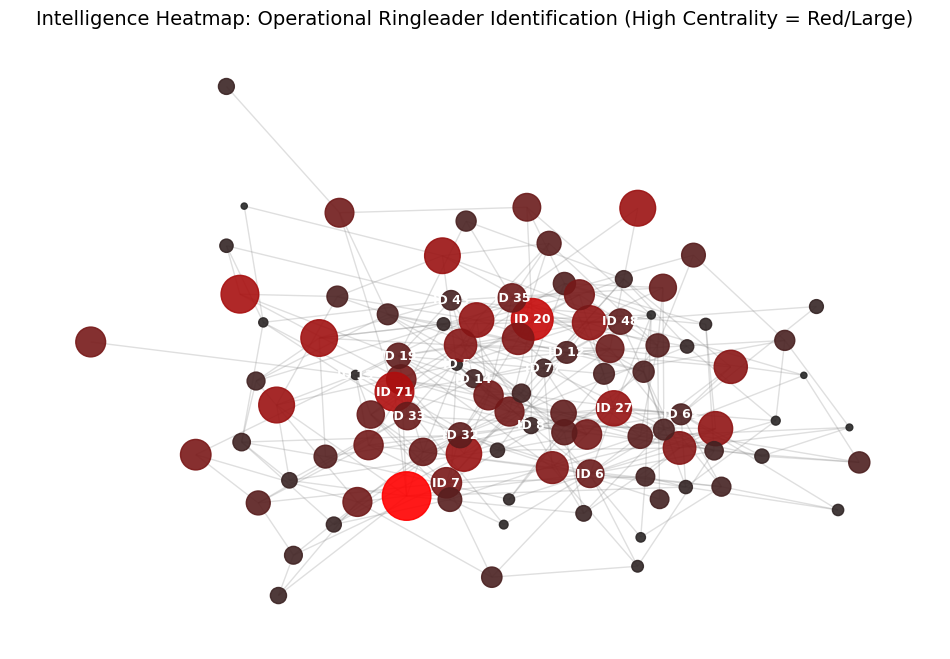

In [21]:
# HIGH-ALERT HEATMAP GRAPH VISUALIZATION (Sample Representative)

print("\nGenerating High-Alert Criminal Heatmap Vector Imagery...")
viz_nodes = 100
viz_edges = 300
viz_network = generate_sparse_network(viz_nodes, viz_edges)

# Calculate centrality scores to scale properties
scores = brandes_betweenness(viz_nodes, viz_network)

# Convert Adjacency List into a NetworkX structure for layout formatting
nx_graph = nx.Graph()
for u in viz_network:
    for v in viz_network[u]:
        nx_graph.add_edge(u, v)

# Configure properties based on centrality scores
max_score = max(scores) if max(scores) > 0 else 1
node_sizes = [20 + (score / max_score) * 1200 for score in scores]

# Map color gradient: low centrality is cool black/grey, high centrality is crimson red
node_colors = []
for score in scores:
    ratio = score / max_score
    # Hex color interpolation ranging from charcoal grey to bright red
    r = int(40 + (ratio * 215))
    g = int(40 * (1 - ratio))
    b = int(40 * (1 - ratio))
    node_colors.append(f"#{r:02x}{g:02x}{b:02x}")

# Generate layout coordinates
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(nx_graph, seed=RANDOM_SEED)

# Render structural components
nx.draw_networkx_edges(nx_graph, pos, alpha=0.25, edge_color="gray")
nx.draw_networkx_nodes(nx_graph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.90)

# Overlay identification labels on high-influence assets
labels = {i: f"ID {i}" for i in range(viz_nodes) if scores[i] > (max_score * 0.4)}
nx.draw_networkx_labels(nx_graph, pos, labels=labels, font_size=9, font_color="white", font_weight="bold")

plt.title("Intelligence Heatmap: Operational Ringleader Identification (High Centrality = Red/Large)", fontsize=14)
plt.axis("off")
plt.show()